# PERSONAGE Evaluation Analysis

This notebook documents the full Big5Loop evaluation pipeline on the PERSONAGE dataset.

## Goals

1. Describe the original data source and which files are used.
2. Reconstruct the preprocessing from PERSONAGE's human ratings into Big5Loop's `[-1, 1]` OCEAN format.
3. Load the workflow evaluation outputs produced by Big5Loop.
4. Compute per-trait Pearson correlation and mean absolute error (MAE).
5. Break down results by condition to understand where the detector is strong or weak.
6. Inspect representative high-error examples for qualitative interpretation.

## Files used

- Raw PERSONAGE source tables:
  - `evaluation_data/raw/predefinedParams.tab`
  - `evaluation_data/raw/randomParams.tab`
- Preprocessed benchmark input:
  - `evaluation_data/personage/processed/personage_eval.jsonl`
- Workflow evaluation output:
  - `evaluation_data/personage/processed/personage_eval_results.jsonl`
- Visualization outputs generated by the scripts:
  - `evaluation_data/personage/processed/personage_summary.csv`
  - `evaluation_data/personage/processed/personage_detected_vs_ground_truth.png`
  - `evaluation_data/personage/processed/personage_metrics.png`

## Dataset composition

The raw PERSONAGE files (`predefinedParams.tab` with 260 rows, `randomParams.tab` with 320 rows) are filtered to retain only utterances with complete annotations across all five OCEAN dimensions. After filtering, **320 valid samples** remain: 160 from predefined personality conditions (20 each for agree_high, agree_low, consc_high, consc_low, ems_high, ems_low, open_high, open_low) and 160 from randomized personality parameter combinations. This constitutes the full evaluation corpus.

## Final results summary (n = 319 valid)

| Trait | Pearson r | p-value | MAE |
|-------|-----------|---------|-----|
| Openness | 0.394 | 2.7e-13 | 0.322 |
| Conscientiousness | 0.419 | 5.1e-15 | 0.393 |
| Extraversion | 0.383 | 1.3e-12 | 0.386 |
| Agreeableness | 0.588 | 4.2e-31 | 0.285 |
| Neuroticism | 0.499 | 1.8e-21 | 0.343 |
| **Mean** | **0.457** | | **0.346** |

All correlations are statistically significant (p < 1e-12). The detector captures meaningful personality signal from single short utterances using 7-example few-shot prompting with Meta Llama 3.3 70B.

In [15]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OCEAN_ORDER = ["O", "C", "E", "A", "N"]
OCEAN_LABELS = {
    "O": "Openness",
    "C": "Conscientiousness",
    "E": "Extraversion",
    "A": "Agreeableness",
    "N": "Neuroticism",
}

def find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / "evaluation_data").exists() and (candidate / "apps").exists():
            return candidate
        if (candidate / "Big5Loop" / "evaluation_data").exists() and (candidate / "Big5Loop" / "apps").exists():
            return candidate / "Big5Loop"
    raise RuntimeError("Could not locate Big5Loop project root from the current working directory.")

PROJECT_ROOT = find_project_root()
EVAL_DIR = PROJECT_ROOT / "evaluation_data"
RAW_DIR = EVAL_DIR / "raw"
PERSONAGE_DIR = EVAL_DIR / "personage"
PROCESSED_DIR = PERSONAGE_DIR / "processed"

PREDEFINED_PATH = RAW_DIR / "predefinedParams.tab"
RANDOM_PATH = RAW_DIR / "randomParams.tab"
EVAL_INPUT_PATH = PROCESSED_DIR / "personage_eval.jsonl"
RESULTS_PATH = PROCESSED_DIR / "personage_eval_results.jsonl"
SUMMARY_CSV_PATH = PROCESSED_DIR / "personage_summary.csv"

print("Project root:", PROJECT_ROOT)
print("Processed dir:", PROCESSED_DIR)
print("Results file exists:", RESULTS_PATH.exists())

Project root: /Users/huaduojiejia/MyProject/hslu/2026/thesis project/Big5Loop
Processed dir: /Users/huaduojiejia/MyProject/hslu/2026/thesis project/Big5Loop/evaluation_data/personage/processed
Results file exists: True


## Data source and preprocessing logic

The raw PERSONAGE files store human ratings on a 1-7 Likert scale:

- `avg.extra` -> Extraversion
- `avg.ems` -> Emotional stability
- `avg.agree` -> Agreeableness
- `avg.consc` -> Conscientiousness
- `avg.open` -> Openness

Big5Loop maps PERSONAGE into its internal OCEAN range `[-1, 1]` using the preprocessing script:

- Scale formula: `(x - 4) / 3`
- Neuroticism is derived from emotional stability:
  - `N = -((avg.ems - 4) / 3)`

This means:

- PERSONAGE rating `4` becomes `0.0` (neutral)
- PERSONAGE rating `7` becomes `+1.0`
- PERSONAGE rating `1` becomes `-1.0`
- High emotional stability becomes low neuroticism

In [16]:
def scale_1_7_to_minus1_1(x):
    return (float(x) - 4.0) / 3.0

def ems_to_neuroticism(ems):
    return -scale_1_7_to_minus1_1(ems)

predefined_df = pd.read_csv(PREDEFINED_PATH, sep="\t")
random_df = pd.read_csv(RANDOM_PATH, sep="\t")

required_cols = ["realization", "avg.extra", "avg.ems", "avg.agree", "avg.consc", "avg.open"]

def full_ocean_rows(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out = out.dropna(subset=["realization", "avg.extra", "avg.agree", "avg.consc", "avg.open"])
    out = out[out["avg.ems"].notna() & (out["avg.ems"] != "n/a")]
    return out

usable_predefined = full_ocean_rows(predefined_df)
usable_random = full_ocean_rows(random_df)

source_summary = pd.DataFrame([
    {
        "source_file": "predefinedParams.tab",
        "rows_total": len(predefined_df),
        "rows_with_full_ocean": len(usable_predefined),
    },
    {
        "source_file": "randomParams.tab",
        "rows_total": len(random_df),
        "rows_with_full_ocean": len(usable_random),
    },
])

display(source_summary)

sample_row = usable_predefined.iloc[0]
sample_mapping = pd.DataFrame([
    {"trait": "O", "raw_personage": sample_row["avg.open"], "mapped_big5loop": scale_1_7_to_minus1_1(sample_row["avg.open"] )},
    {"trait": "C", "raw_personage": sample_row["avg.consc"], "mapped_big5loop": scale_1_7_to_minus1_1(sample_row["avg.consc"] )},
    {"trait": "E", "raw_personage": sample_row["avg.extra"], "mapped_big5loop": scale_1_7_to_minus1_1(sample_row["avg.extra"] )},
    {"trait": "A", "raw_personage": sample_row["avg.agree"], "mapped_big5loop": scale_1_7_to_minus1_1(sample_row["avg.agree"] )},
    {"trait": "N", "raw_personage": sample_row["avg.ems"], "mapped_big5loop": ems_to_neuroticism(sample_row["avg.ems"] )},
])

print("Example PERSONAGE utterance:")
print(sample_row["realization"])
display(sample_mapping)

,source_file,rows_total,rows_with_full_ocean
0,predefinedParams.tab,260,160
1,randomParams.tab,320,160


Example PERSONAGE utterance:
Did you say Acacia and Marinella? I imagine you would appreciate them, you see? It seems to me that Marinella provides kind of satisfactory food, also it's an italian place mate, but Acacia offers sort of acceptable food, you know.


,trait,raw_personage,mapped_big5loop
0,O,4.25,0.083333
1,C,5.75,0.583333
2,E,5.50,0.500000
3,A,6.00,0.666667
4,N,6.50,-0.833333


In [17]:
def load_jsonl(path: Path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows

eval_rows = load_jsonl(EVAL_INPUT_PATH)
results_rows = load_jsonl(RESULTS_PATH)
valid_results = [
    row for row in results_rows
    if row.get("ground_truth_ocean") and row.get("detected_ocean")
]

print(f"Benchmark inputs: {len(eval_rows)}")
print(f"Workflow outputs: {len(results_rows)}")
print(f"Valid scored outputs: {len(valid_results)}")

records = []
for row in valid_results:
    rec = {
        "id": row["id"],
        "input": row["input"],
        "input_len": len(row["input"]),
        "condition": str(row["id"]).split("-")[0],
        "template": str(row["id"]).split("-")[1] if "-" in str(row["id"]) else "unknown",
        "error": row.get("error"),
    }
    for trait in OCEAN_ORDER:
        rec[f"gt_{trait}"] = float(row["ground_truth_ocean"][trait])
        rec[f"det_{trait}"] = float(row["detected_ocean"][trait])
        rec[f"abs_err_{trait}"] = abs(rec[f"det_{trait}"] - rec[f"gt_{trait}"])
        rec[f"signed_err_{trait}"] = rec[f"det_{trait}"] - rec[f"gt_{trait}"]
    records.append(rec)

df = pd.DataFrame(records)
df.head()

Benchmark inputs: 320
Workflow outputs: 320
Valid scored outputs: 319


,id,input,input_len,condition,template,error,gt_O,det_O,abs_err_O,signed_err_O,...,abs_err_E,signed_err_E,gt_A,det_A,abs_err_A,signed_err_A,gt_N,det_N,abs_err_N,signed_err_N
0,agree_high-compare2-Acacia-Marinella-4,Did you say Acacia and Marinella? I imagine yo...,231,agree_high,compare2,None,0.083333,0.2,0.116667,0.116667,...,0.200000,-0.200000,0.666667,0.7,0.033333,0.033333,-0.833333,-0.6,0.233333,0.233333
1,agree_high-compare2-Caffe_Cielo-Trattoria_Spag...,Let's see what we can find on Caffe Cielo and ...,303,agree_high,compare2,None,0.416667,0.1,0.316667,-0.316667,...,0.466667,-0.466667,0.500000,0.5,0.000000,0.000000,-0.666667,-0.4,0.266667,0.266667
2,agree_high-compare2-Ikeno_Hana-Menchanko-Tei-4,Let's see what we can find on Ikeno Hana and M...,236,agree_high,compare2,None,0.583333,0.1,0.483333,-0.483333,...,0.383333,-0.383333,0.750000,0.7,0.050000,-0.050000,-0.666667,-0.4,0.266667,0.266667
3,agree_high-compare2-Kin_Khao-Tossed-4,"Did you say Kin Khao and Tossed? Oh yeah, I wo...",172,agree_high,compare2,None,-0.166667,0.2,0.366667,0.366667,...,0.200000,0.200000,0.583333,0.7,0.116667,0.116667,-0.250000,-0.4,0.150000,-0.150000
4,agree_high-compare2-Le_Rivage-Pintaile_s_Pizza-4,You want to know more about Le Rivage and Pint...,287,agree_high,compare2,None,0.083333,0.5,0.416667,0.416667,...,0.100000,0.100000,0.416667,0.7,0.283333,0.283333,-0.333333,-0.8,0.466667,-0.466667


In [18]:
def safe_corr(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if len(x) < 2 or np.std(x) < 1e-9 or np.std(y) < 1e-9:
        return np.nan
    return float(np.corrcoef(x, y)[0, 1])

metric_rows = []
for trait in OCEAN_ORDER:
    gt = df[f"gt_{trait}"]
    det = df[f"det_{trait}"]
    metric_rows.append({
        "trait": trait,
        "label": OCEAN_LABELS[trait],
        "pearson_r": safe_corr(gt, det),
        "mae": float(np.mean(np.abs(det - gt))),
        "mean_gt": float(np.mean(gt)),
        "mean_det": float(np.mean(det)),
        "mean_signed_error": float(np.mean(det - gt)),
        "std_det": float(np.std(det)),
    })

metrics_df = pd.DataFrame(metric_rows)
metrics_df["pearson_r"] = metrics_df["pearson_r"].round(3)
metrics_df["mae"] = metrics_df["mae"].round(3)
metrics_df["mean_gt"] = metrics_df["mean_gt"].round(3)
metrics_df["mean_det"] = metrics_df["mean_det"].round(3)
metrics_df["mean_signed_error"] = metrics_df["mean_signed_error"].round(3)
metrics_df["std_det"] = metrics_df["std_det"].round(3)
display(metrics_df)

print("Overall mean Pearson r:", round(metrics_df["pearson_r"].mean(), 3))
print("Overall mean MAE:", round(metrics_df["mae"].mean(), 3))

,trait,label,pearson_r,mae,mean_gt,mean_det,mean_signed_error,std_det
0,O,Openness,0.394,0.322,-0.048,-0.080,-0.032,0.342
1,C,Conscientiousness,0.419,0.393,0.192,0.152,-0.039,0.512
2,E,Extraversion,0.383,0.386,0.178,0.135,-0.044,0.348
3,A,Agreeableness,0.588,0.285,0.233,0.212,-0.021,0.426
4,N,Neuroticism,0.499,0.343,-0.212,-0.156,0.057,0.407


Overall mean Pearson r: 0.457
Overall mean MAE: 0.346


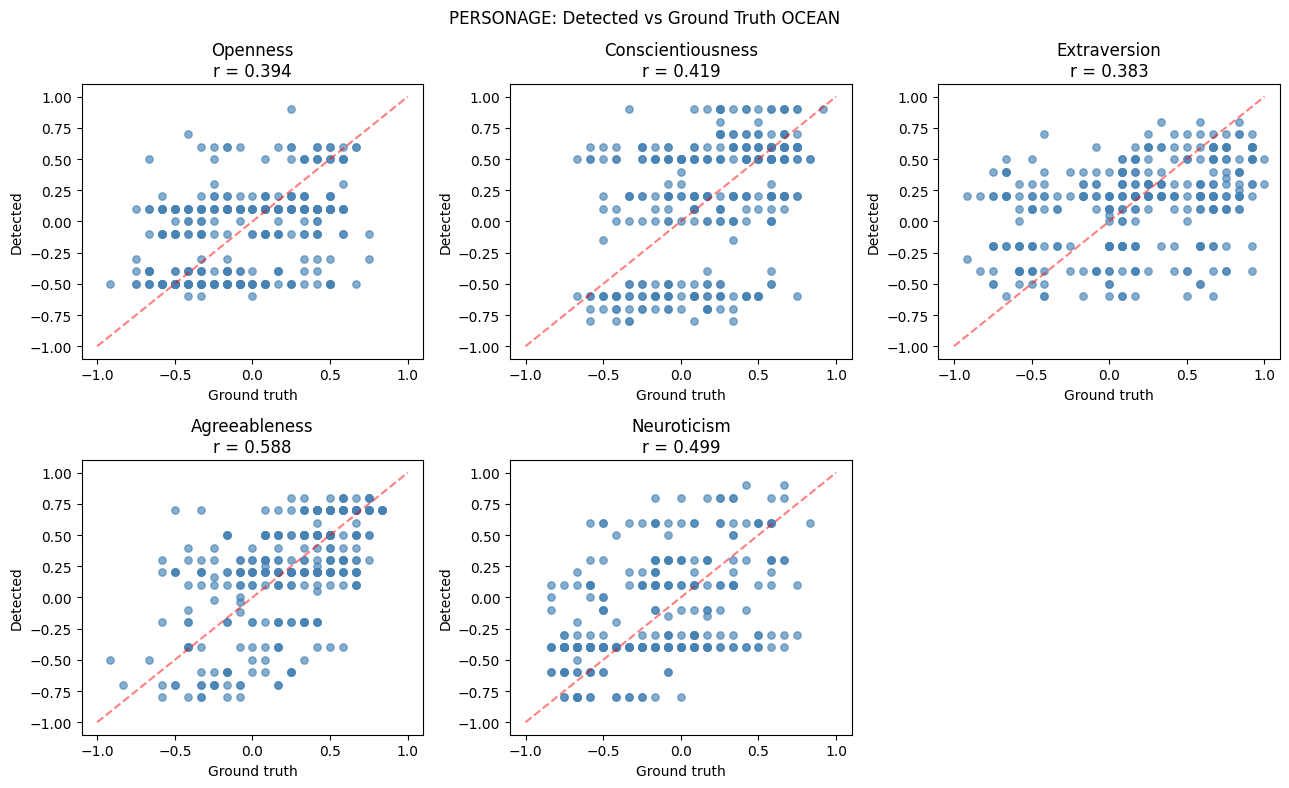

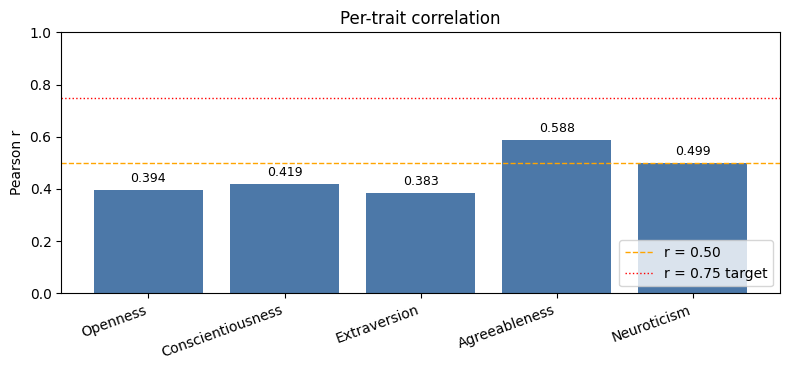

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes = axes.flatten()

for idx, trait in enumerate(OCEAN_ORDER):
    ax = axes[idx]
    gt = df[f"gt_{trait}"].to_numpy()
    det = df[f"det_{trait}"].to_numpy()
    r = safe_corr(gt, det)
    ax.scatter(gt, det, alpha=0.65, s=28, color="steelblue")
    ax.plot([-1, 1], [-1, 1], "r--", alpha=0.5)
    ax.set_title(f"{OCEAN_LABELS[trait]}\nr = {r:.3f}")
    ax.set_xlabel("Ground truth")
    ax.set_ylabel("Detected")
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)

axes[-1].axis("off")
fig.suptitle("PERSONAGE: Detected vs Ground Truth OCEAN")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 3.8))
bars = ax.bar(metrics_df["label"], metrics_df["pearson_r"], color="#4C78A8")
ax.axhline(0.5, color="orange", linestyle="--", linewidth=1, label="r = 0.50")
ax.axhline(0.75, color="red", linestyle=":", linewidth=1, label="r = 0.75 target")
ax.set_ylabel("Pearson r")
ax.set_ylim(0, 1)
ax.set_title("Per-trait correlation")
ax.legend(loc="lower right")
for bar, val in zip(bars, metrics_df["pearson_r"]):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.02, f"{val:.3f}", ha="center", va="bottom", fontsize=9)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

,condition,trait,pearson_r,mae,n
0,agree_high,O,0.230300,0.217500,20
1,agree_high,C,-0.189369,0.214167,20
2,agree_high,E,0.354268,0.301667,20
3,agree_high,A,0.073425,0.175833,20
4,agree_high,N,-0.123409,0.260833,20
5,agree_low,O,0.047580,0.239167,20
6,agree_low,C,-0.211312,0.325000,20
7,agree_low,E,0.581123,0.410833,20
8,agree_low,A,0.483929,0.375833,20
9,agree_low,N,-0.393885,0.473333,20


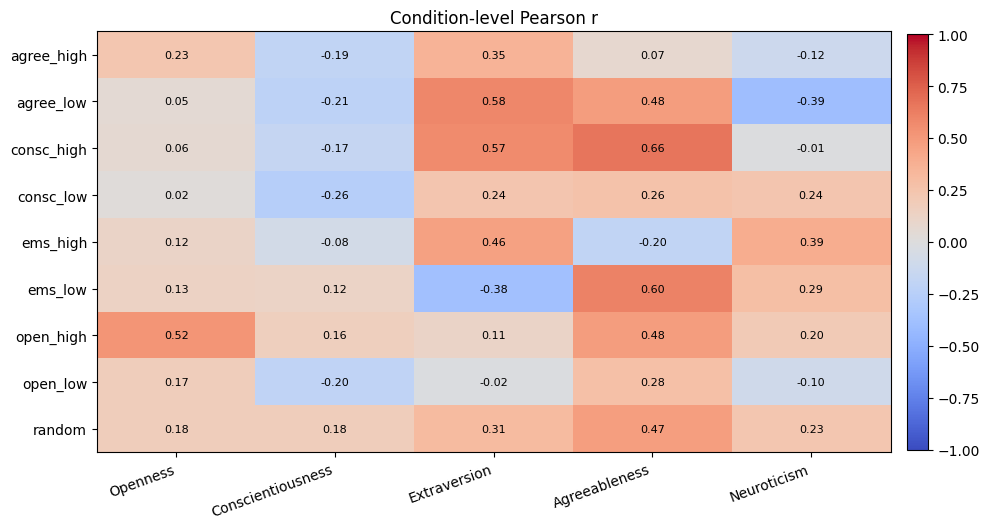

,condition,template,n
0,agree_high,compare2,10
1,agree_high,recommend,10
2,agree_low,compare2,10
3,agree_low,recommend,10
4,consc_high,compare2,10
5,consc_high,recommend,10
6,consc_low,compare2,10
7,consc_low,recommend,9
8,ems_high,compare2,10
9,ems_high,recommend,10


In [20]:
condition_metrics = []
for condition, group in df.groupby("condition"):
    for trait in OCEAN_ORDER:
        condition_metrics.append({
            "condition": condition,
            "trait": trait,
            "pearson_r": safe_corr(group[f"gt_{trait}"], group[f"det_{trait}"]),
            "mae": float(np.mean(np.abs(group[f"det_{trait}"] - group[f"gt_{trait}"]))),
            "n": len(group),
        })

condition_df = pd.DataFrame(condition_metrics)
condition_pivot = condition_df.pivot(index="condition", columns="trait", values="pearson_r").reindex(columns=OCEAN_ORDER)
display(condition_df.head(10))

fig, ax = plt.subplots(figsize=(10, max(4, 0.6 * len(condition_pivot))))
im = ax.imshow(condition_pivot.to_numpy(), aspect="auto", cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(OCEAN_ORDER)))
ax.set_xticklabels([OCEAN_LABELS[t] for t in OCEAN_ORDER], rotation=20, ha="right")
ax.set_yticks(range(len(condition_pivot.index)))
ax.set_yticklabels(condition_pivot.index)
ax.set_title("Condition-level Pearson r")
for i in range(condition_pivot.shape[0]):
    for j in range(condition_pivot.shape[1]):
        val = condition_pivot.iloc[i, j]
        label = "nan" if pd.isna(val) else f"{val:.2f}"
        ax.text(j, i, label, ha="center", va="center", fontsize=8, color="black")
plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
plt.tight_layout()
plt.show()

condition_counts = df.groupby(["condition", "template"]).size().reset_index(name="n")
display(condition_counts.sort_values(["condition", "template"]))

In [21]:
def show_worst_examples(trait: str, n: int = 5):
    cols = ["id", "condition", "template", "input", f"gt_{trait}", f"det_{trait}", f"abs_err_{trait}", f"signed_err_{trait}"]
    out = df[cols].sort_values(f"abs_err_{trait}", ascending=False).head(n).copy()
    out = out.rename(columns={
        f"gt_{trait}": "ground_truth",
        f"det_{trait}": "detected",
        f"abs_err_{trait}": "abs_error",
        f"signed_err_{trait}": "signed_error",
    })
    return out

weakest_trait = metrics_df.sort_values("pearson_r").iloc[0]["trait"]
strongest_trait = metrics_df.sort_values("pearson_r", ascending=False).iloc[0]["trait"]

print("Weakest trait:", weakest_trait, OCEAN_LABELS[weakest_trait])
display(show_worst_examples(weakest_trait, n=5))

print("Strongest trait:", strongest_trait, OCEAN_LABELS[strongest_trait])
display(show_worst_examples(strongest_trait, n=5))

Weakest trait: E Extraversion


,id,condition,template,input,ground_truth,detected,abs_error,signed_error
66,consc_low-compare2-Mavalli_Palace-Once_Upon_A_...,consc_low,compare2,"I might be darn wrong! Err... I mean, I might ...",0.916667,-0.4,1.316667,-1.316667
113,ems_low-recommend-Jin_Dal_Lae-1,ems_low,recommend,I might be damn wrong. Jin Dal Lae is the only...,0.666667,-0.6,1.266667,-1.266667
245,random-recommend-Cent_anni-16,random,recommend,"I mean, I might be sort of wrong. Because Cent...",-0.666667,0.5,1.166667,1.166667
61,consc_low-compare2-Caffe_Cielo-Trattoria_Spagh...,consc_low,compare2,"I might be wrong! I mean, there could be worse...",0.750000,-0.4,1.150000,-1.150000
281,random-recommend-John_s_Pizzeria-12,random,recommend,"I am not sure. Basically, I believe you would ...",-0.750000,0.4,1.150000,1.150000


Strongest trait: A Agreeableness


,id,condition,template,input,ground_truth,detected,abs_error,signed_error
281,random-recommend-John_s_Pizzeria-12,random,recommend,"I am not sure. Basically, I believe you would ...",-0.500000,0.7,1.200000,1.200000
227,random-compare2-Scopa-Shabu-Tatsu-14,random,compare2,"Right, everybody knows that you would probably...",-0.333333,0.7,1.033333,1.033333
166,random-compare2-Acacia-Marinella-9,random,compare2,"Basically, I believe Acacia and Marinella are ...",0.583333,-0.4,0.983333,-0.983333
32,agree_low-recommend-Edgar_s_Cafe-3,agree_low,recommend,"Basically, I mean, I thought everybody knew th...",0.500000,-0.4,0.900000,-0.900000
150,open_low-recommend-Chimichurri_Grill-7,open_low,recommend,"Err... I am not sure. Mmhm... I mean, Chimichu...",-0.583333,0.3,0.883333,0.883333


## How to interpret the notebook outputs

- **Pearson r** measures whether the detector preserves the relative ranking of speakers on each trait.
- **MAE** measures how far the predicted trait scores are from the ground-truth scores in absolute magnitude.
- **Mean signed error** helps detect systematic overestimation or underestimation.
- **Condition-level analysis** shows whether performance depends on the PERSONAGE manipulation category (for example, `agree_high`, `agree_low`, or other profile groups in the full set).
- **Worst-case examples** are useful for qualitative discussion in the manuscript because they expose calibration failures that summary statistics alone do not show.

## Suggested use in the thesis

This notebook supports both the methods and results sections:

1. In **Methods / Evaluation**, cite the raw source files, the rating transformation, and the single-turn workflow evaluation setup.
2. In **Results**, report the per-trait `r` and MAE values from the metrics table.
3. In **Discussion**, use the condition breakdown and worst examples to explain where the workflow transfers well and where domain mismatch remains.

If you rerun `scripts/run_personage_eval.py`, this notebook should refresh automatically as long as `personage_eval_results.jsonl` is updated.